In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import minimize

# Import Data

In [16]:
# 1. Data Import ————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————
# Read Excel files
sig_file = pd.ExcelFile("SSE50_Enhanced_sig.xlsx")
factor_file = pd.ExcelFile("Single_Factor_Set.xlsx")
# Get all sheet names
sig_names = sig_file.sheet_names
factor_names = factor_file.sheet_names
# Now access different DataFrames through dictionary
df_ret = pd.read_excel(sig_file, sig_names[3], index_col=0)
df_free_value = pd.read_excel(factor_file, factor_names[0], index_col=0)
df_turnover_rate = pd.read_excel(factor_file, factor_names[1], index_col=0)
df_dy = pd.read_excel(factor_file, factor_names[2], index_col=0)
df_mom = pd.read_excel(factor_file, factor_names[3], index_col=0)
df_std = pd.read_excel(factor_file, factor_names[4], index_col=0)
# Preprocess factors to make them all positive linear factors (similar to operations in machine learning)
df_mom=-df_mom
df_std = -(abs(df_std.sub(df_std.median(axis=1),axis=0)))
# Combine factor list
dfs=[df_free_value,df_turnover_rate,df_dy,df_mom,df_std]
# Shift ret forward by one period for easier calculation
df_ret=df_ret.shift(-1).fillna(0)

# Maximize ICIR Method

In [19]:
# 2. Maximize ICIR Method ————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————
ic_results = []
# Iterate through each DataFrame and calculate rank correlation with ret_factor (no lag here, apply lag in weight part for better rationality)
for df in dfs:
    df_rank=df.rank(axis=1)
    ret_factor=df.notna().astype(int)*df_ret
    ret_factor.replace(0, np.nan, inplace=True)
    ret_rank=ret_factor.rank(axis=1)
    ic = df_rank.corrwith(ret_rank, axis=1)
    ic_results.append(ic)
ics = pd.concat(ic_results, axis=1)

# Objective function (maximize ICIR, since we use minimize function, add negative sign here)
def objective_function(x):
    if (np.linalg.norm(x@ics_t_cov@x.T))==0:
        icir=0
    else:
        icir=-np.linalg.norm(np.dot(x, ics_t.T)) / (np.linalg.norm(x@ics_t_cov@x.T))**0.5
    return icir

w=[]
for t in range(1,len(ics)):
    ics_t=ics.iloc[:t+1]#Need to analyze whether to start from beginning or use rolling 12-24 periods, opinions vary
    ics_t_cov=ics_t.cov(ddof=0)
    ics_t=np.asmatrix(ics_t.mean())
    # Initial guess value
    x0 = np.array([1, 3,6,10,1])
    # Call minimize function, add equality and inequality constraints
    result = minimize(
        objective_function, 
        x0, 
        method='SLSQP',
        bounds=[(0, None), (0, None),(0, None),(0, None),(0, None)]  # Set bounds for x, since we've converted to positive factors, avoid negative weights
    )
    w_t=result.x.copy()
    w_t=pd.DataFrame(w_t).T
    w_t=w_t.apply(lambda x: x/x.sum(),axis=1)
    w.append(w_t)
w=pd.concat(w, ignore_index=True)
w_0 = pd.DataFrame(0, index=[0], columns=w.columns)
w=pd.concat([w_0,w], ignore_index=True)
# Must lag by one period
w=w.shift(1).fillna(0)
# Since different factors have different missing values after processing, we need to handle this part
a=(df_free_value.notna()|df_turnover_rate.notna()|df_dy.notna()|df_mom.notna()|df_std.notna())*1
a.replace(0, np.nan, inplace=True)
df_factor=(df_free_value.fillna(0)*a).multiply(w[0].values, axis=0)+(df_turnover_rate.fillna(0)*a).multiply(w[1].values, axis=0)+(df_dy.fillna(0)*a).multiply(w[2].values, axis=0)\
    +(df_mom.fillna(0)*a).multiply(w[3].values, axis=0)+(df_std.fillna(0)*a).multiply(w[4].values, axis=0)
del(a)

# Group testing

In [21]:
# 3. Group Testing ————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————
# Calculate thresholds for dividing into 5 groups after removing NaN values (sorted equal division method)
g=5
g_p = [i / g for i in range(1, g)]
thresholds_factor = df_factor.apply(lambda row: list(row.dropna().nlargest(int(len(row.dropna()) * p)).min() for p in g_p), axis=1)
# Alternative method (quantile equal division, usable but less common, introduces factor values into grouping)
#thresholds_factor = df_factor.apply(lambda row: list(row.dropna().quantile([0.2, 0.4, 0.6, 0.8])), axis=1)
# Assign group labels based on thresholds
factor_group = df_factor.apply(lambda row: row.apply(lambda x: sum(x >= t for t in thresholds_factor[row.name]) + 1 if pd.notnull(x) else np.nan), axis=1)

# Calculate group returns and net values
# Adjust ret to match df_factor's NaN structure
ret_factor=df_factor.notna().astype(int)*df_ret
ret_factor.replace(0, np.nan, inplace=True)
ret = []
jz= []

# Equal weighting within each group
for i in range(1, g+1):
    ret_i = (factor_group == i) * ret_factor
    ret_i.replace(0, np.nan, inplace=True)
    ret_i=ret_i.mean(axis=1)
    ret_i.fillna(0,inplace=True)
    ret.append(ret_i)
    # Convert returns to growth rates
    growth_rates = 1 + ret_i
    jz_i= np.cumprod(growth_rates)
    jz.append(jz_i)

# Evaluation index calculation

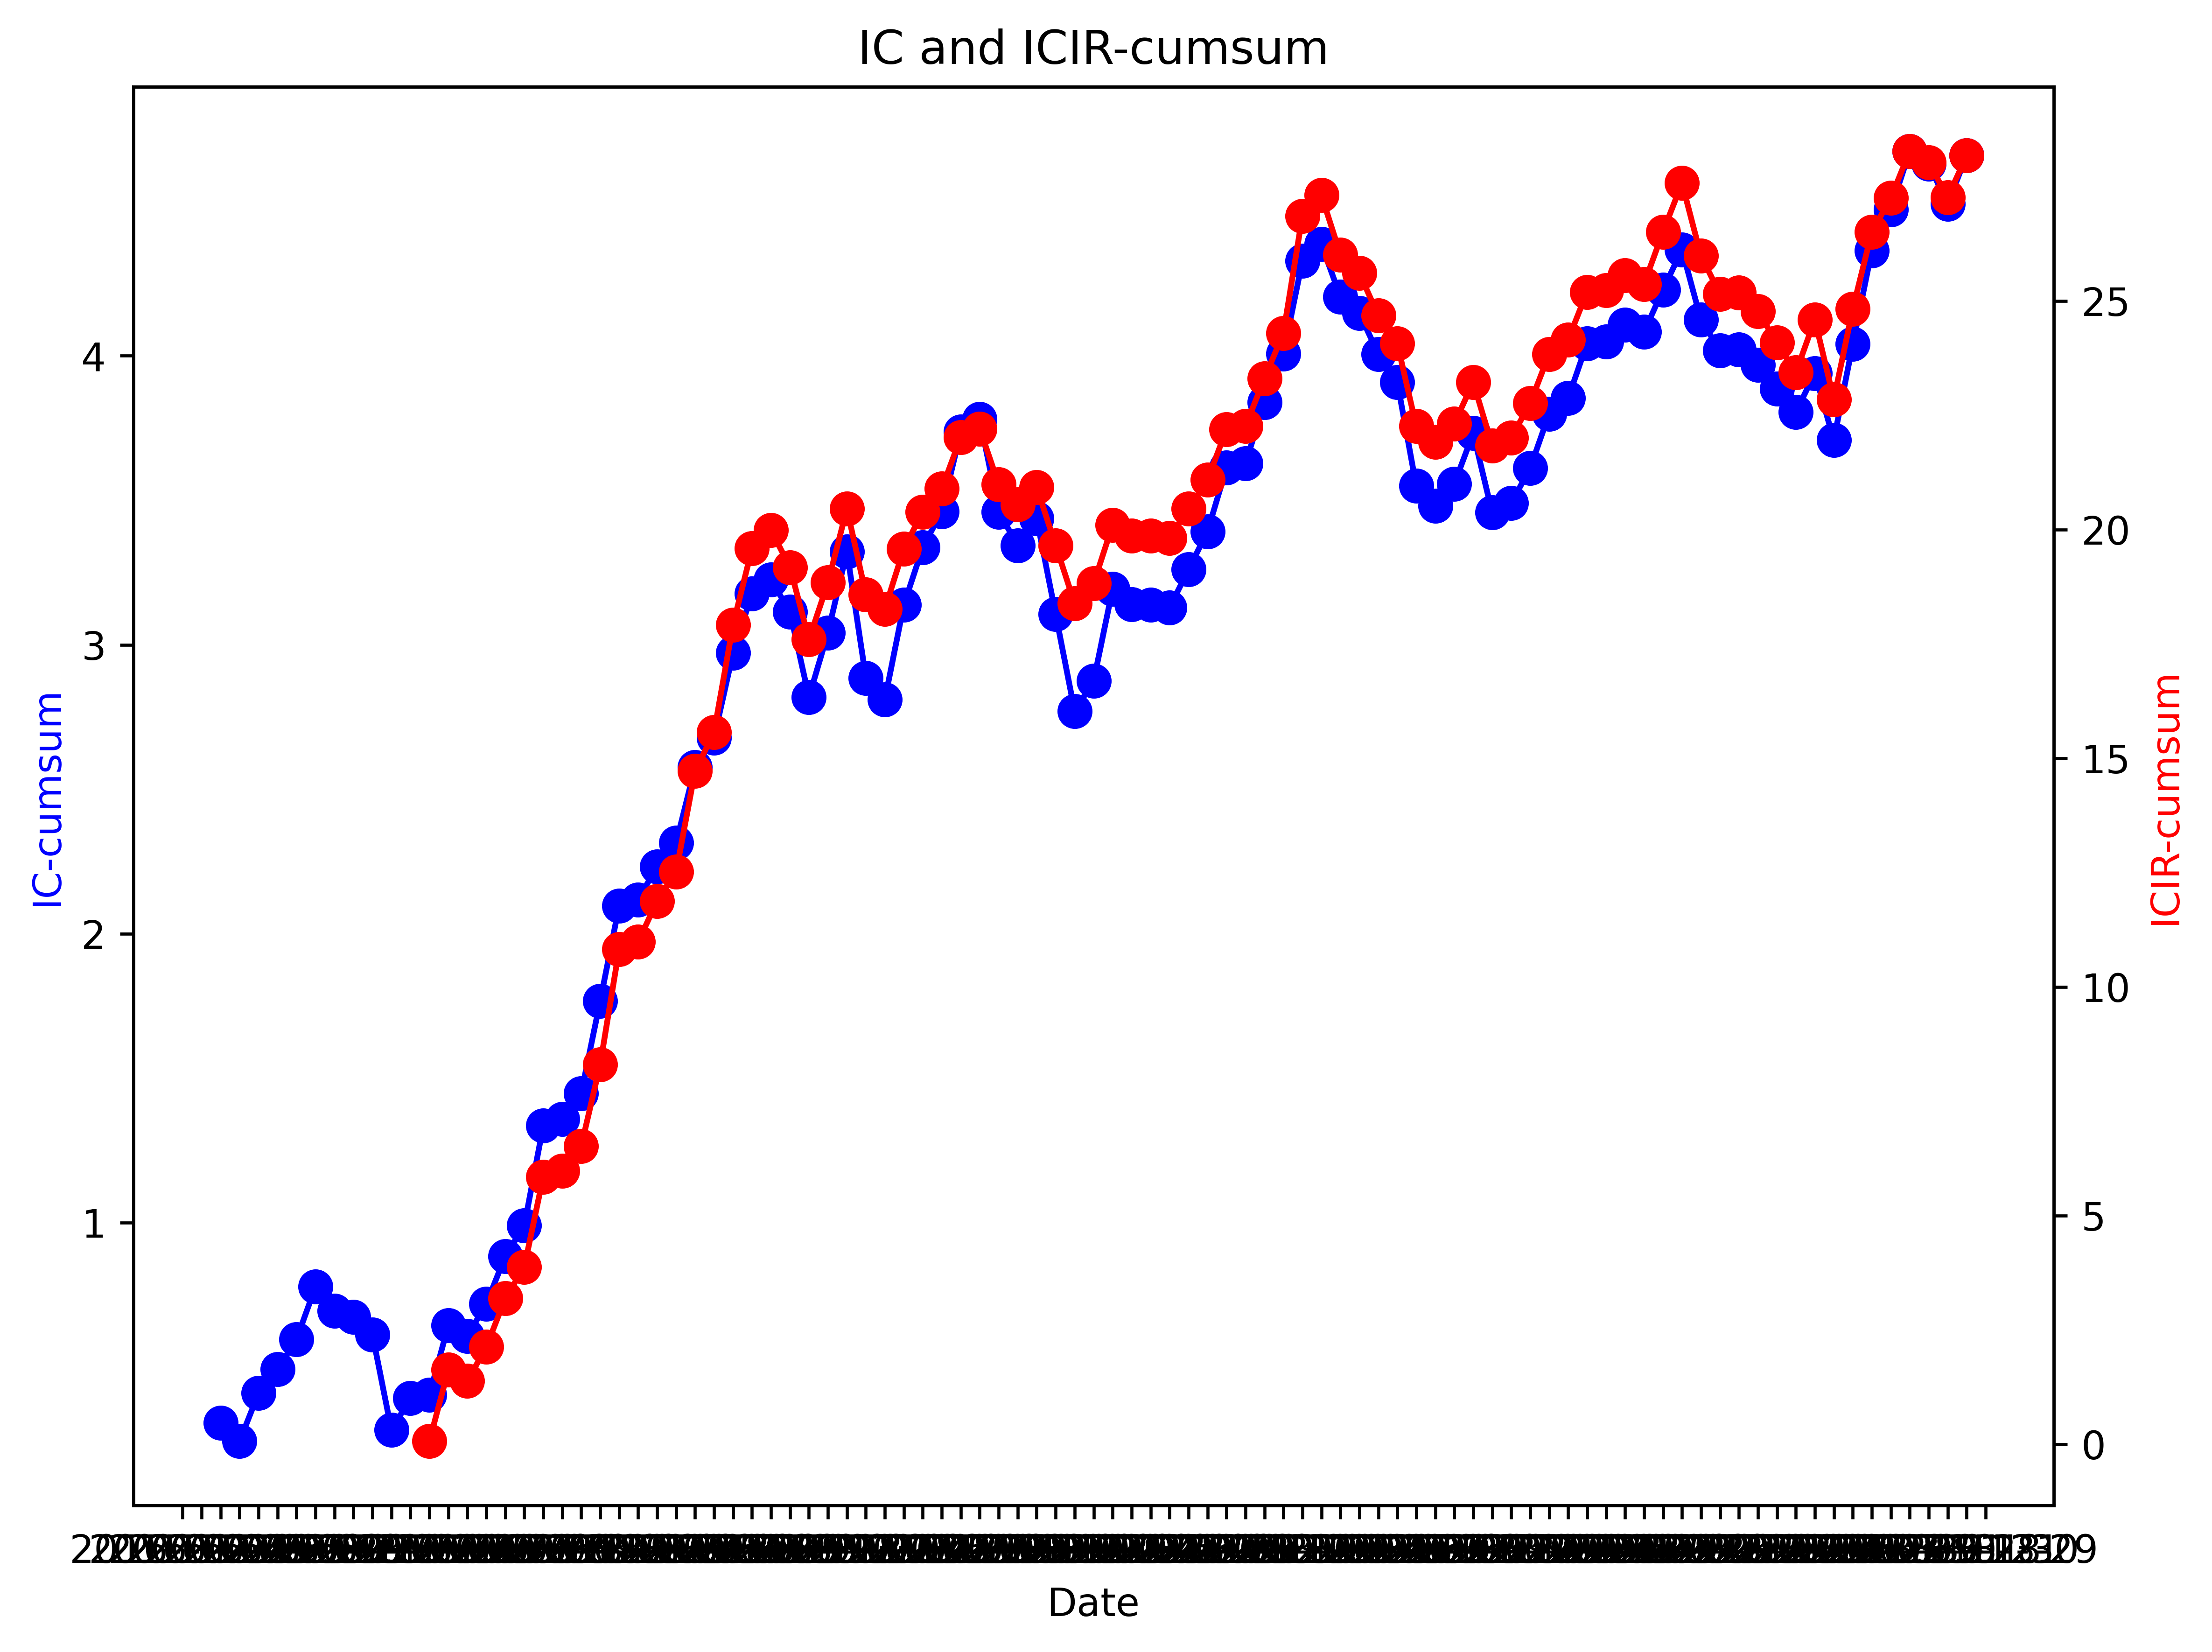

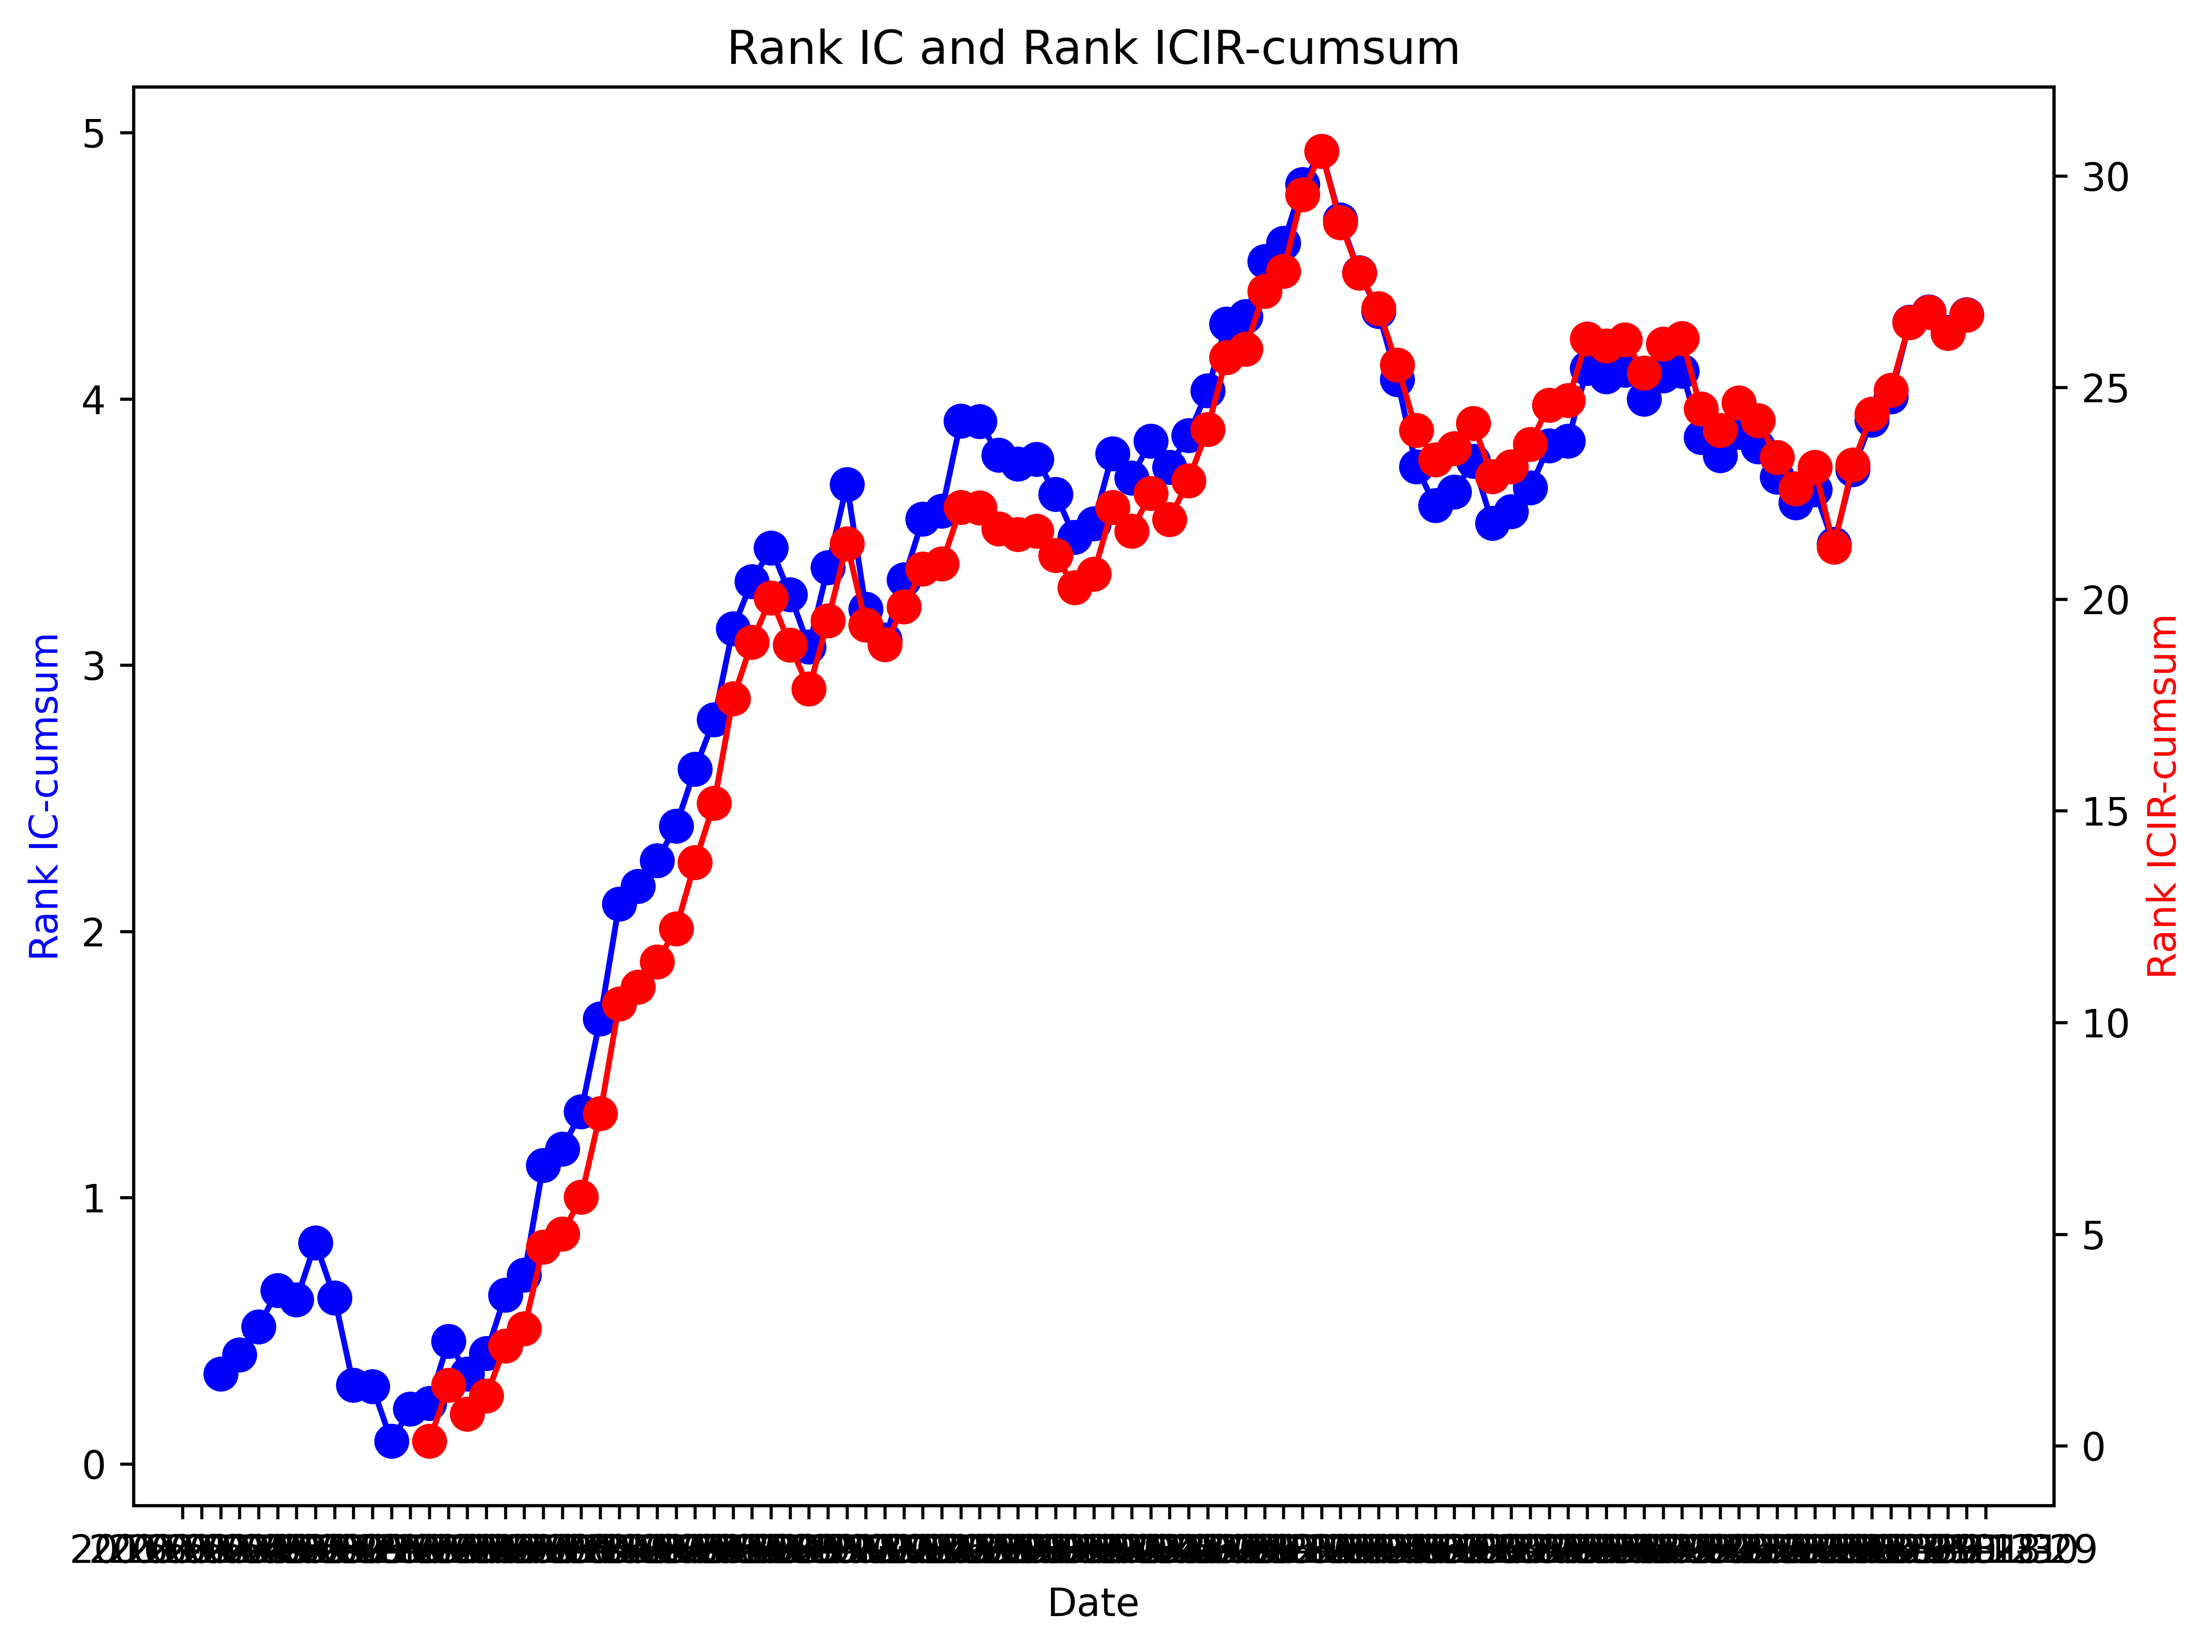

In [25]:
# 4. Evaluation Metrics Calculation ————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————
# Calculate IC and Rank IC
ret_rank = ret_factor.rank(axis=1)
factor_rank = df_factor.rank(axis=1)
ic = df_factor.corrwith(ret_factor, axis=1)
rankic = factor_rank.corrwith(ret_rank, axis=1)
icir = ic / (ic.rolling(12).std())  # Rolling 12-month IC volatility
rankicir = rankic / (rankic.rolling(12).std())
ic_cumsum = ic.cumsum()
icir_cumsum = icir.cumsum()
rankic_cumsum = rankic.cumsum()
rankicir_cumsum = rankicir.cumsum()

# ——————————————————————————————————— IC/RANKIC Plotting ———————————————————————————————————
def plot_dual_axis_bar_line(df1, df2, ylabel1, ylabel2, title):
    fig, ax1 = plt.subplots(figsize=(8, 6), dpi=600)
    # Plot primary axis bar chart for first column
    ax1.plot(df1.index.strftime('%Y-%m-%d'), df1, marker='o', linestyle='-', color='b', markersize=8)
    ax1.set_xlabel('Date')
    ax1.set_ylabel(ylabel1, color='b')
    # Create secondary axis
    ax2 = ax1.twinx()
    # Plot secondary axis line chart for second column
    ax2.plot(df2.index.strftime('%Y-%m-%d'), df2, marker='o', linestyle='-', color='r', markersize=8)
    ax2.set_ylabel(ylabel2, color='r')
    # Add title
    plt.title(title)
    # Adjust layout to prevent overlap
    fig.tight_layout()
    # Display plot
    plt.show()

# Plot first set of data
plot_dual_axis_bar_line(ic_cumsum, icir_cumsum, 'IC-cumsum', 'ICIR-cumsum', 'IC and ICIR-cumsum')
# Plot second set of data
plot_dual_axis_bar_line(rankic_cumsum, rankicir_cumsum, 'Rank IC-cumsum', 'Rank ICIR-cumsum', 'Rank IC and Rank ICIR-cumsum')

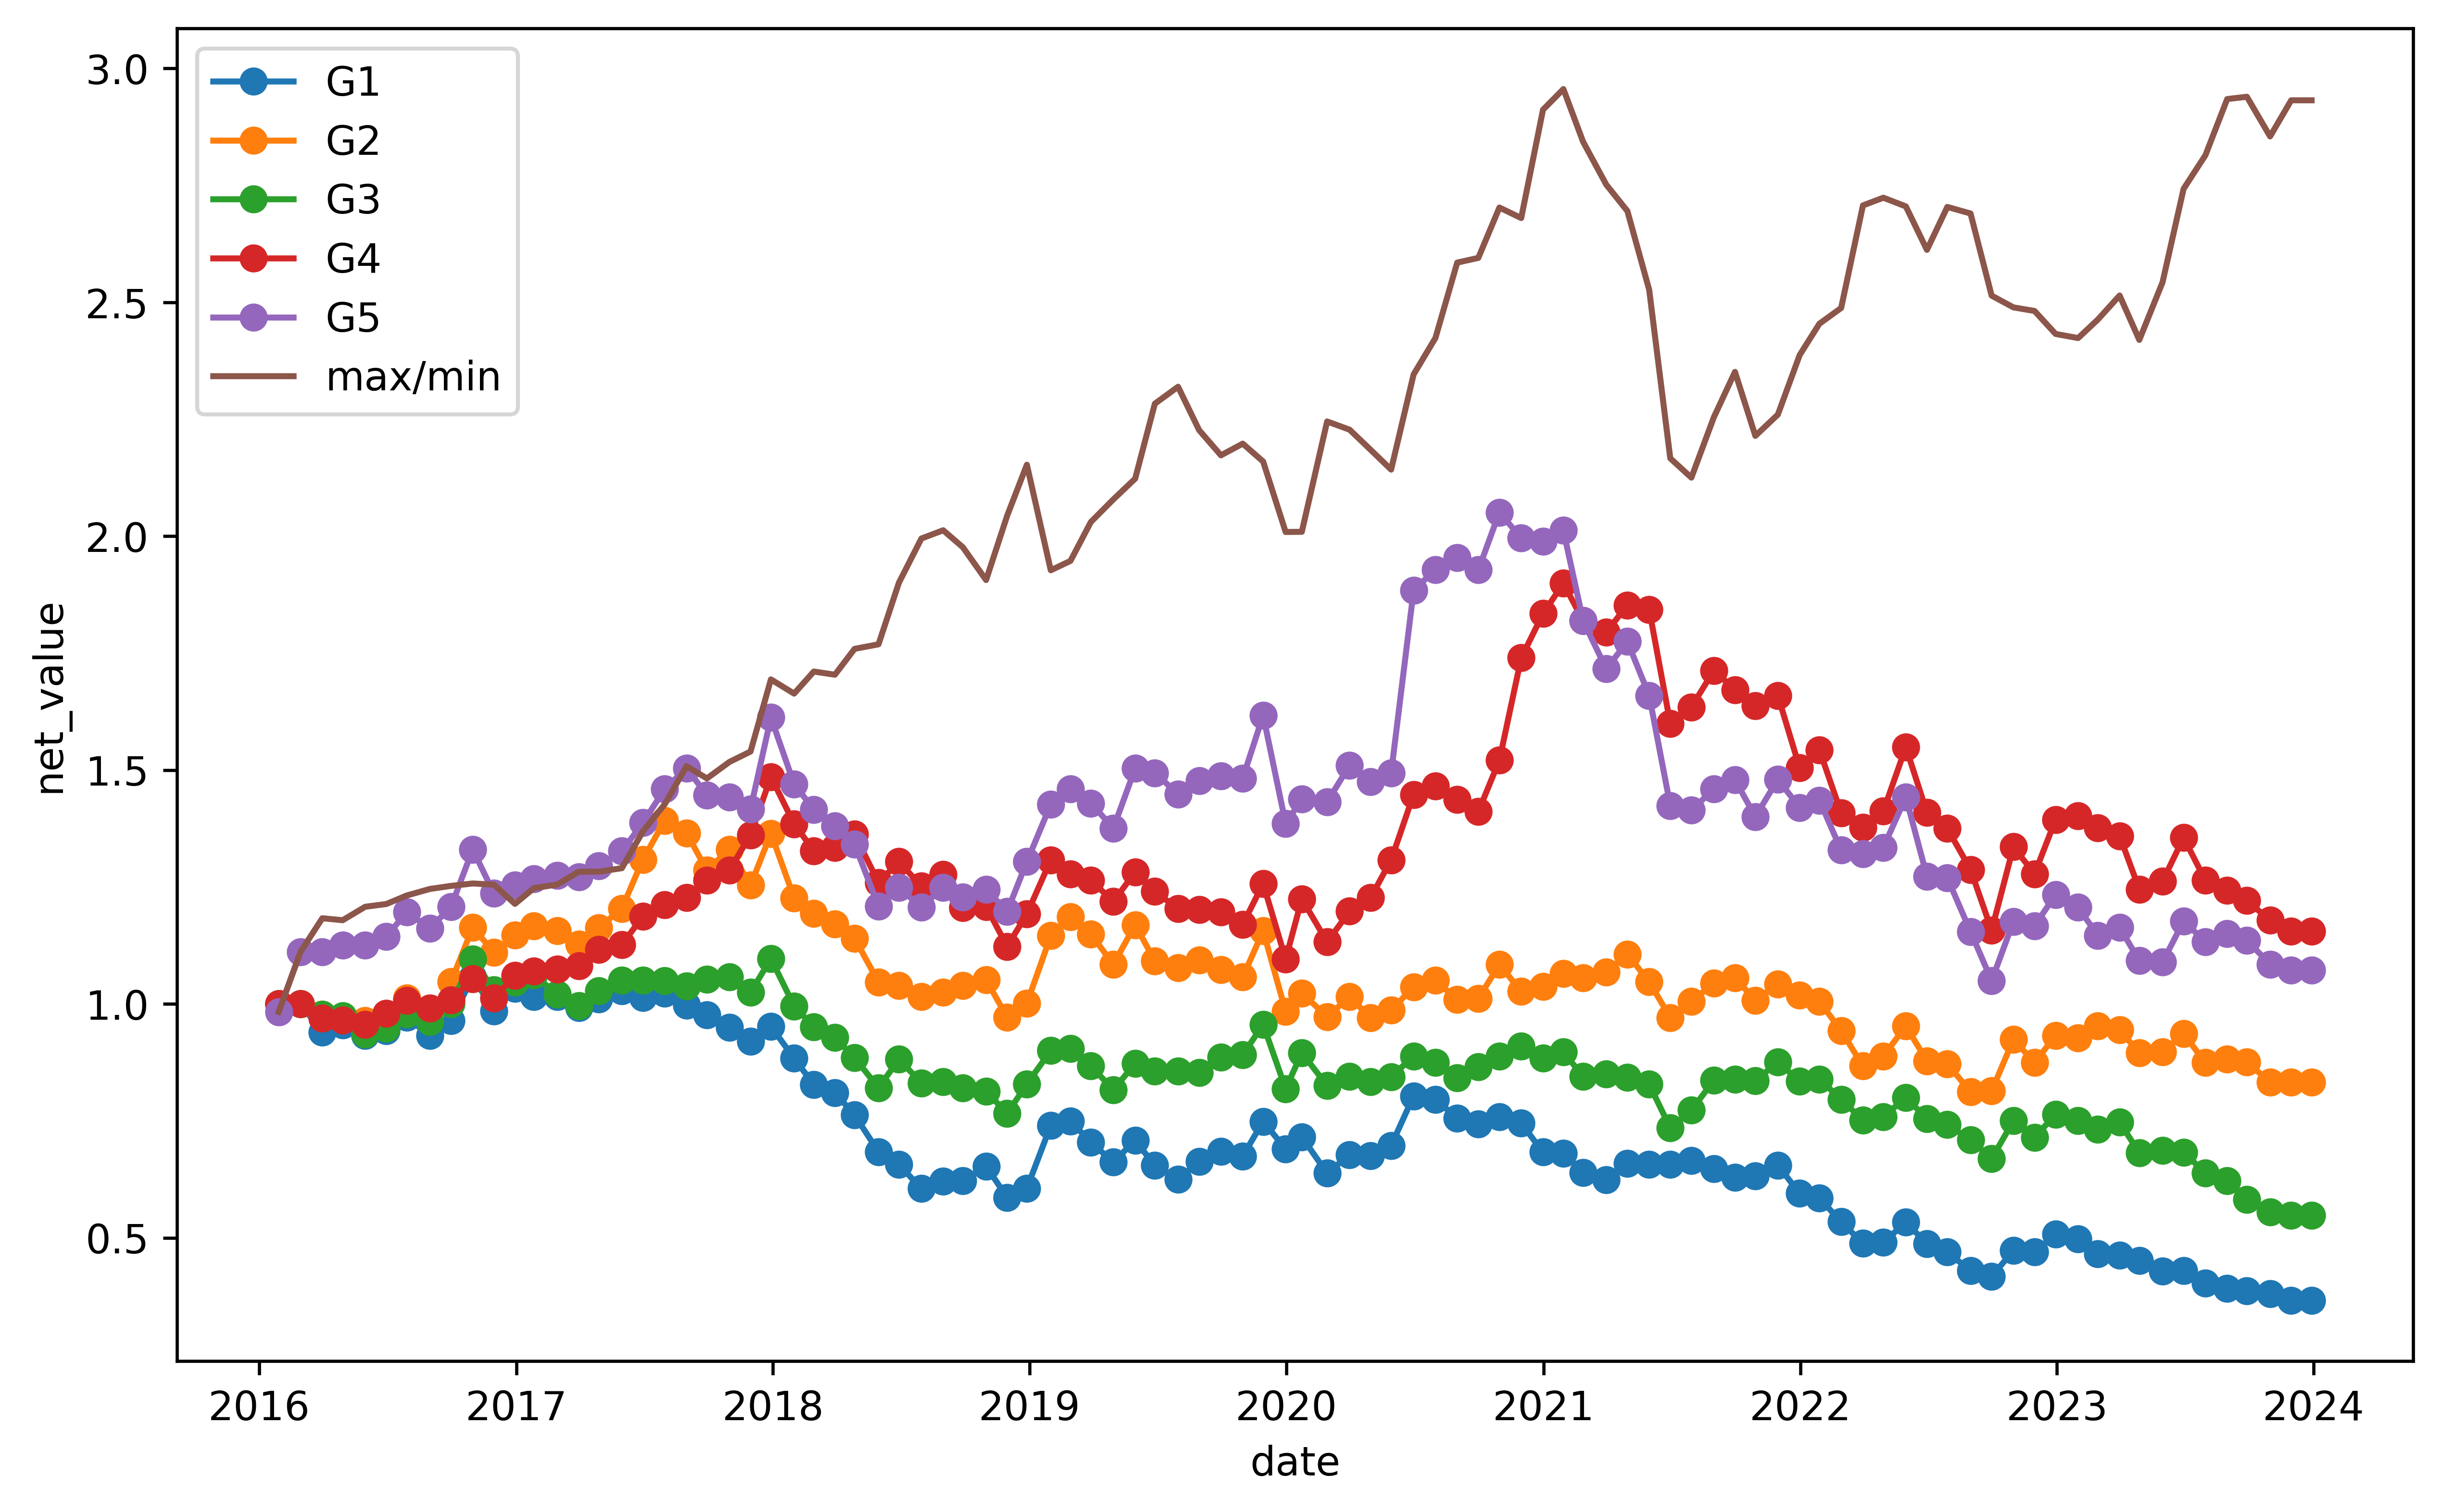

In [27]:
# ———————————————————————————————————— Net Value Plotting —————————————————————————————————————————————————————————
plt.figure(figsize=(10, 6), dpi=600)
# Plot each Series in the list as a line chart
g = 0
for jz_i in jz:
    g = g + 1
    plt.plot(jz_i.index, jz_i.values, marker='o', linestyle='-', label=f'Group {g}')
plt.plot(jz[(g-1)]/jz[0], label='Max/Min Ratio')
# Add title and labels
plt.xlabel('Date')
plt.ylabel('Net Value')
# Add legend
plt.legend()
# Display the plot
plt.show()